In [1]:
#Notebook 2 ---> 
#Building : Neupert Constrained Cross Attention Neural Network 


#We are building a thermodynami engine where : 
#1-Non-thermal electron acceleration (Hard X-rays, HEL1OS) acts as the **Query**.
# - Coronal plasma heating (Soft X-rays, SoLEXS) acts as the **Key/Value**.

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, optimizers

# Setting plot style
plt.style.use('dark_background')
tf.random.set_seed(42)
np.random.seed(42)


2026-06-27 06:28:27.219396: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782541707.245278     116 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782541707.253293     116 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782541707.272612     116 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782541707.272633     116 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782541707.272636     116 computation_placer.cc:177] computation placer alr

In [3]:
import numpy as np
import pickle
import json

EXPORT_DIR = "/kaggle/input/datasets/tamish03/nc2an-export"

train_features = np.load(f"{EXPORT_DIR}/train_features.npy")
train_labels   = np.load(f"{EXPORT_DIR}/train_labels.npy")

val_features   = np.load(f"{EXPORT_DIR}/val_features.npy")
val_labels     = np.load(f"{EXPORT_DIR}/val_labels.npy")

with open(f"{EXPORT_DIR}/feature_names.pkl","rb") as f:
    feature_names = pickle.load(f)

with open(f"{EXPORT_DIR}/metadata.pkl","rb") as f:
    metadata = pickle.load(f)

with open(f"{EXPORT_DIR}/config.pkl","rb") as f:
    config = pickle.load(f)

print(train_features.shape)
print(train_labels.shape)

(34548, 5)
(34548,)


In [4]:
WINDOW_SIZE = 60
STRIDE = 5
BATCH_SIZE = 32

train_dataset = tf.keras.utils.timeseries_dataset_from_array(
    data=train_features[:-WINDOW_SIZE],
    targets=train_labels[WINDOW_SIZE:],
    sequence_length=WINDOW_SIZE,
    sequence_stride=STRIDE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_dataset = tf.keras.utils.timeseries_dataset_from_array(
    data=val_features[:-WINDOW_SIZE],
    targets=val_labels[WINDOW_SIZE:],
    sequence_length=WINDOW_SIZE,
    sequence_stride=STRIDE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

I0000 00:00:1782541712.685781     116 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782541712.691598     116 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [5]:


batch_x, batch_y = next(iter(train_dataset))

print(batch_x.shape)
print(batch_y.shape)

# Split into HEL1OS and SoLEXS streams

hard_input = batch_x[:, :, 0:1]     # Hard
soft_input = batch_x[:, :, 1:]      # Soft + H/S + dSoft/dt + Energy

print(hard_input.shape)
print(soft_input.shape)

(32, 60, 5)
(32,)
(32, 60, 1)
(32, 60, 4)


In [6]:
print(train_features.shape)
print(train_labels.shape)

print(feature_names)

(34548, 5)
(34548,)
['Hard', 'Soft', 'H/S', 'dSoft/dt', 'Energy']


In [7]:
# Concept : When the expensive NC2AN model should even wake up actually 

#1-HEL1OS Stream -> CUSUM Sentinal-> Quiet-> Sleep 
#2- HEL1OS Stream -> CUSUM Sentinal-> Possible Flare-> Wake NC2AN 

#Flux_stream= inputs 
#Threshold : Based on Suspicion score ,How suspicious should the Sun becomes before the wakeup call 
#Drift= What if I becoe suspicious but then everything becomes normal ? , Forget old suspicions slowly 
#alpha : How quicly should backgroud learns based on morning ,afternoon ,evening and night 
#Median_win : always look at last 5 values 
def cusum_trigger(flux_stream,threshold=5.0,drift=0.1,alpha=0.05,median_win=5):
    smoothed_flux= np.copy(flux_stream)
    for t in range(len(flux_stream)):
        start= max(0,
                  t-median_win+1) # How far should i look back ? = 5 readings 
        smoothed_flux[t]= np.median(flux_stream[start:t+1]) # Cosmic ray gone 

    S= np.zeros_like(smoothed_flux) # Makes a ist of 0 suspicion score initially 
    trigger_points=[] # Times whn i give wakeup call 
    
    ema_mean= np.mean(smoothed_flux[:100]) # What does normal sun look like 
    ema_var= np.var(smoothed_flux[:100])+1e-8 # How much does noraml sun wiggles 
    
    # Now actual wakeup system call method : 
    for t in range(1,len(smoothed_flux)):
        ema_std= np.sqrt(ema_var)
        deviation= (smoothed_flux[t]-ema_mean)/(ema_std+1e-8) #How weird is actuall currrent reading 
        S[t]= max(0,S[t-1]+deviation-drift)
        #Dynamic wakeup calling : 
        if S[t]<threshold : 
            diff= smoothed_flux[t]-ema_mean
            ema_mean+= alpha*diff
            ema_var+= alpha*(diff*diff-ema_var)
            ema_var= max(1e-8,ema_var)

        else:
            trigger_points.append(t)

            S[t]=0 # Reset the CUSUM Score 

    return S ,trigger_points 
            
        
        
    
    
    

In [8]:
# Use first real HEL1OS window

real_flux = hard_input[0, :, 0].numpy()

S_scores, triggers = cusum_trigger(
    real_flux,
    threshold=10,
    drift=0.5
)

In [9]:
S_scores

array([0.        , 7.02644443, 6.25375759, 6.30985622, 5.51159165,
       4.72155752, 3.93949093, 3.16514024, 2.39826435, 1.63863208,
       0.88602157, 0.14021971, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

In [10]:
triggers

[]

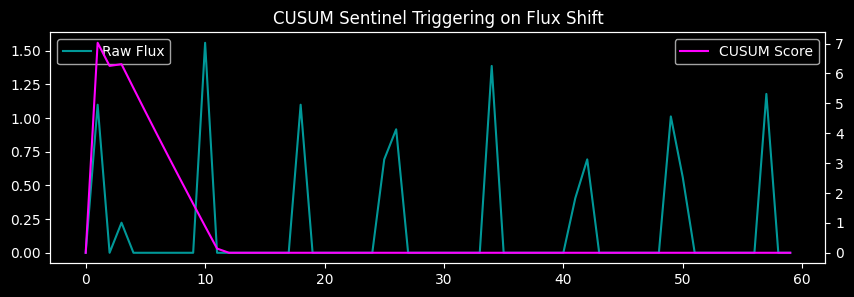

In [11]:
fig, ax1 = plt.subplots(figsize=(10, 3))
ax2 = ax1.twinx()

ax1.plot(real_flux, color='cyan', alpha=0.6, label='Raw Flux')
ax2.plot(S_scores, color='magenta', label='CUSUM Score')
if triggers:
    ax1.axvline(triggers[0], color='red', linestyle='--', label='Trigger Fired!')

ax1.set_title("CUSUM Sentinel Triggering on Flux Shift")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

In [12]:
#Entering the Actual Pipeline : 
#CUSUM says --> Wake up -->Computer cuts the 60-minute window of the data 
#Yes -> Extract the last 60 min-> [Time * 5 features]-> Goes to 1D CNN Encoder for Local Temporl Feature Extraction 

# We are using the Residual Dilated CNN Block :
#1- Dilated Convolutions -> Instead of walking every house ,Ill jumo every second house .Now i see more area 
#2-Residual Connection -> Suppose it learned garbage -> garbage + Originality-> Preserved originality-> Prevents the garbage output 
#3-Layer Normalization -> To stabilize the training from gradients and variances 


class GatedConv1D(layers.Layer):
    def __init__(self,filters,kernel_size,dilation_rate=1,**kwargs):
        super(GatedConv1D,self).__init__(**kwargs)
        self.filters=filters
        self.kernel_size=kernel_size,
        self.dilation_rate=dilation_rate

        #Filters=  Filters*2= Team A + Team b = Core of GLU 
        #Team A will become a value for team B and it will verify for the pass 
        #Team A = I found a flare ,Team B = Are you really sure? 
        self.conv= layers.Conv1D(filters=filters*2,kernel_size=kernel_size,
                                padding='same',dilation_rate=dilation_rate)

    
    def call(self,x):
        out= self.conv(x)
        val,gate= tf.split(out,num_or_size_splits=2,axis=-1)
        return val*tf.sigmoid(gate) # This is the core of Gated Linear Unit 


    def get_config(self):
        config = super(GatedConv1D, self).get_config()
        config.update({
            "filters": self.filters,
            "kernel_size": self.kernel_size,
            "dilation_rate": self.dilation_rate
        })
        return config
        
    

In [13]:
#Multiple CNN + Residual Connections + Layer Norm --> Encoder 

class TemporalEncoder(layers.Layer):
    def __init__(self,embed_dim=64,**kwargs):
        super(TemporalEncoder,self).__init__(**kwargs)
        self.embed_dim= embed_dim
        self.input_proj= layers.Conv1D(filters=embed_dim,kernel_size=1,padding='same')
        self.input_proj = layers.Conv1D(filters=embed_dim, kernel_size=1, padding='same')
        self.gated_conv1 = GatedConv1D(filters=embed_dim, kernel_size=5, dilation_rate=1)
        self.gated_conv2 = GatedConv1D(filters=embed_dim, kernel_size=3, dilation_rate=2)
        self.gated_conv3 = GatedConv1D(filters=embed_dim, kernel_size=3, dilation_rate=4)
        self.ln1 = layers.LayerNormalization(epsilon=1e-6)
        self.ln2 = layers.LayerNormalization(epsilon=1e-6)
        self.ln3 = layers.LayerNormalization(epsilon=1e-6)

    def call(self,x):
        x_proj= self.input_proj(x) # [32*60*5]-->[32*60*embed_dim]
        h1= self.gated_conv1(x_proj)# Lets inspect small local flare patterns 
        h1= self.ln1(x_proj+h1) # Layer Normalization + Residual Conections 
        h2= self.gated_conv2(h1) # Now lets inspect wider pattersn 
        h2 = self.ln2(h1 + h2) # Layer Normalization + Residual Connections 
        h3 = self.gated_conv3(h2) # Now lets inspect maginfying patterns 
        out = self.ln3(h2 + h3) # Layer Normalization + Residual Connections 
        return out


    def get_config(self):
        config = super(TemporalEncoder, self).get_config()
        config.update({
            "embed_dim": self.embed_dim
        })
        return config
    

In [14]:
#Making Encoders for HEL1OS and SOLEXS : 

hard_encoder= TemporalEncoder(embed_dim=64)
soft_encoder= TemporalEncoder(embed_dim=64)

In [15]:
enc_hard = hard_encoder(hard_input)
enc_soft = soft_encoder(soft_input)



print(f"Encoded HEL1OS Shape: {enc_hard.shape}  -> [Batch, SeqLen, EmbedDim]")
print(f"Encoded SoLEXS Shape: {enc_soft.shape}  -> [Batch, SeqLen, EmbedDim]")
assert enc_hard.shape == (32, 60, 64)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'temporal_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
I0000 00:00:1782541716.101804     116 cuda_dnn.cc:529] Loaded cuDNN version 91002


Encoded HEL1OS Shape: (32, 60, 64)  -> [Batch, SeqLen, EmbedDim]
Encoded SoLEXS Shape: (32, 60, 64)  -> [Batch, SeqLen, EmbedDim]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'temporal_encoder_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [16]:
# Positional Encoding : How do I know which second this is ? 
# Here Realtive Time is > Absolute Time 

# Relative Time : 30 sec --> Time lapse between hard X-ray and Soft-x ray 
# Absolute Time : 9AM ,10AM


# Explanation : 
# Flare A : 10:00-> hard spike ,10:00:30-> soft spike 
# Flare B : 5:00-> hard spike ,5:00:30->soft spike 

#Conclusion : Physics dosent care whether the flare happend at 10 or 5 
#Result : Physics only care about the time interval -> 30 seconds . 
                   #----This is called Neupert Effect ----#

#Method to be used : 
#RoPE : Rotatory Positional Encoding 
#Meaning : Represents positional information by rotating the vectors instead of adding position directly into the data 
#Every postion has the unique angle 


In [17]:
#Simple Sinusoidal Positional Encoding :
class PositionalEncoding(layers.Layer):
    #max_len = prepare position ids for n seconds 
    def __init__(self,max_len=5000,encoding_type='sinusoidal',**kwargs):
        super(PositionalEncoding,self).__init__(**kwargs)
        self.max_len=max_len
        self.encoding_type=encoding_type
        self.pe=None # Will create it later ...

    def build(self,input_shape):
        embed_dim= input_shape[-1]
        if self.encoding_type=='sinusoidal':
            pe= np.zeros(
                (5000,64)
            )
            position= np.arange(0,self.max_len) # Creates positions in order 
            position= position[:,np.newaxis]
            #Creating own signature frequencies 
            div_term = np.exp(np.arange(0, embed_dim, 2) * -(np.log(10000.0) / embed_dim))
            # Even -> sin ,odd-> cos
            pe[:, 0::2] = np.sin(position * div_term)
            pe[:, 1::2] = np.cos(position * div_term)
            self.pe = tf.constant(pe, dtype=tf.float32)[tf.newaxis, :, :]
        super(PositionalEncoding, self).build(input_shape)


    def call(self, x):
        if self.encoding_type == 'sinusoidal' and self.pe is not None:
            seq_len = tf.shape(x)[1]
            return x + self.pe[:, :seq_len, :]
        return x # Identity for 'rope' or 'none'

    def get_config(self):
        config = super(PositionalEncoding, self).get_config()
        config.update({
            "max_len": self.max_len,
            "encoding_type": self.encoding_type
        })
        return config

pos_encoder = PositionalEncoding(encoding_type='sinusoidal')

#enc_hard = pos_encoder(enc_hard)
#enc_soft = pos_encoder(enc_soft)

#print(f"Positionally encoded shape remains: {enc_hard.shape}")

    

            
        
        

In [18]:
#RoPE Positional Encoding : 


# Query Shape ; [Batch ,SeqLen,Heads,HeadDim]->[32,60,8,8]
#x shape = [Query]
def apply_rope(x,cos,sin):
    #Splitting the vector into two halves :
    x1,x2= tf.split(
        x,num_or_size_splits=2,axis=-1
    )
    #Rotation : (x,y)--> Rotate 90 degree--> (-y,x):
    rotated_x= tf.concat(
        [-x2,x1],
        axis=-1
    )
    return x*cos + rotated_x*sin

#Explanation :
#[4,8,3,7,2,6]-->x1=[4,8,3], x2=[7,2,6]--> [-7,-2,-6,4,8,3]--> 0.8*[4,8,3,7,2,6] + 0.6*[-7,-2,-6,4,8,3]
#Final Query vecror :[-1.0,5.2,-1.2,8.0,6.4,6.6]
    


In [19]:
# =============================================================================
#                    WHY ROTARY POSITION EMBEDDING (RoPE)?
# =============================================================================
#
# Problem with Absolute Position
# ------------------------------
# Consider two physically identical solar flares.
#
# Flare A
# --------
# Hard X-Ray Spike : 10:00:00
# Soft X-Ray Spike : 10:00:30
#
# Delay = 30 seconds
#
#
# Flare B
# --------
# Hard X-Ray Spike : 17:00:00
# Soft X-Ray Spike : 17:00:30
#
# Delay = 30 seconds
#
#
# Physically,
#
#       Flare A  ==  Flare B
#
# because the Neupert Effect only cares about
#
#       Hard X-Ray
#             ↓
#          ~30 sec
#             ↓
#        Soft X-Ray
#
# NOT
#
#       "10 AM"
#
# or
#
#       "5 PM"
#
#
# -----------------------------------------------------------------------------
# What happens with Sinusoidal Positional Encoding?
# -----------------------------------------------------------------------------
#
# Sinusoidal Encoding injects the ABSOLUTE position directly into embeddings.
#
# Example
#
# Position 100
#     ↓
# Embedding + Position(100)
#
# Position 3500
#     ↓
# Embedding + Position(3500)
#
# Although both flares have exactly the same 30-second delay,
# their embeddings become significantly different because
# absolute position has been added.
#
#
# -----------------------------------------------------------------------------
# RoPE thinks differently.
# -----------------------------------------------------------------------------
#
# RoPE never asks:
#
#       "Did this happen at 10 AM?"
#
# Instead it asks:
#
#       "How far apart are these two events?"
#
#
# Imagine Position 100 rotates the Query vector by
#
#       20°
#
# while Position 130 rotates it by
#
#       26°
#
#
# Relative Rotation
#
#       26° - 20°
#
#            =
#
#            6°
#
#
# Now another flare happens much later...
#
# Hard Spike
# Position = 3500
#
# Rotation
#
#       720°
#
#
# Soft Spike
# Position = 3530
#
# Rotation
#
#       726°
#
#
# Relative Rotation
#
#       726° - 720°
#
#             =
#
#             6°
#
#
# Notice something beautiful...
#
# Absolute angles changed dramatically
#
#       20°
#          ↓
#       720°
#
# BUT
#
# the relative angle remained IDENTICAL
#
#       6°
#
# This is the entire magic of RoPE.
#
#
# -----------------------------------------------------------------------------
# Think of a Clock
# -----------------------------------------------------------------------------
#
# Today
#
#       10:00
#          ↓
#       10:30
#
# Difference
#
#       30 minutes
#
#
# Tomorrow
#
#       17:00
#          ↓
#       17:30
#
# Difference
#
#       30 minutes
#
#
# The clock time changed.
#
# The delay DID NOT.
#
# RoPE behaves exactly like this.
#
#
# -----------------------------------------------------------------------------
# How Attention sees this
# -----------------------------------------------------------------------------
#
# Suppose after RoPE rotation
#
# Hard Query
#
#       [-1.0,
#         5.2,
#        -1.2,
#         8.0,
#         6.4,
#         6.6]
#
#
# Soft Key
#
#       [-2.0,
#         4.0,
#         0.0,
#         9.0,
#         5.0,
#         7.0]
#
#
# Attention computes
#
#       Query • Key
#
#
# Since BOTH vectors were rotated according to position,
# their dot-product naturally depends on
#
#       Relative Position
#
# instead of
#
#       Absolute Position
#
#
# -----------------------------------------------------------------------------
# Computer's Internal Thinking
# -----------------------------------------------------------------------------
#
# ❌ I DO NOT care if this happened at 10 AM.
#
# ❌ I DO NOT care if this happened at 5 PM.
#
# ✅ I ONLY care how much these two vectors rotated
#    relative to each other.
#
#
# -----------------------------------------------------------------------------
# Dance Analogy
# -----------------------------------------------------------------------------
#
# Rahul
#
#       Facing North
#
#
# Amit
#
#       Facing North-East
#
#
# Relative Angle
#
#       45°
#
#
# Tomorrow
#
# Rahul
#
#       Facing South
#
#
# Amit
#
#       Facing South-East
#
#
# Relative Angle
#
#       45°
#
#
# Rahul changed orientation.
#
# Amit changed orientation.
#
# BUT
#
# Their relationship never changed.
#
# RoPE only preserves this RELATIONSHIP.
#
#
# -----------------------------------------------------------------------------
# Why this is Perfect for NC²AN
# -----------------------------------------------------------------------------
#
# Neupert Effect:
#
#       Hard X-Ray
#             ↓
#          ~30 sec
#             ↓
#       Soft X-Ray
#
#
# NOT
#
#       Hard X-Ray at 10:00
#             ↓
#       Soft X-Ray at 10:00:30
#
#
# The Sun does NOT care what your wristwatch says.
#
# The Sun only cares about
#
#       Energy Injection
#               ↓
#            Time Delay
#               ↓
#       Thermal Plasma Response
#
# RoPE naturally encodes this delay.
#
#
# -----------------------------------------------------------------------------
# Final Picture
# -----------------------------------------------------------------------------
#
# Without RoPE
#
#       10:00 ----------> Soft
#
#       17:00 ----------> Soft
#
# Transformer thinks
#
#       Different Events
#
#       ❌
#
#
# With RoPE
#
#       Hard ----30 sec----> Soft
#
#       Hard ----30 sec----> Soft
#
# Transformer thinks
#
#       Same Physical Relationship
#
#       ✅
#
#
# =============================================================================
# THE ONE SENTENCE TO REMEMBER FOREVER
# =============================================================================
#
# RoPE never teaches the Transformer
#
#       "This happened at 10 AM."
#
# RoPE teaches
#
#       "These two events are 30 seconds apart."
#
# Relative timing emerges naturally through the geometry of
# rotated Query and Key vectors instead of being stored as
# absolute timestamps.
#
# This makes RoPE exceptionally suitable for physics-based
# time-series such as solar flare forecasting.
# =============================================================================

In [20]:
# Generate RoPE Cosine & Sine Tables 

def get_rope_cos_sin(seq_len, head_dim):
   

    # Rotation frequency for every dimension pair
    theta = 1.0 / (
        10000.0 **
        (
            tf.cast(tf.range(0, head_dim, 2), tf.float32)
            / tf.cast(head_dim, tf.float32)
        )
    )

    # Position indices
    positions = tf.cast(
        tf.range(seq_len),
        tf.float32
    )

    # Position × Frequency
    # Shape : [SeqLen, HeadDim/2]
    freqs = tf.einsum(
        "i,j->ij",
        positions,
        theta
    )

    # Duplicate frequencies
    # Shape : [SeqLen, HeadDim]
    freqs = tf.concat(
        [freqs, freqs],
        axis=-1
    )

    # Cosine & Sine tables
    # Shape : [1, SeqLen, 1, HeadDim]
    cos = tf.expand_dims(
            tf.expand_dims(
                tf.cos(freqs),
                axis=0
            ),
            axis=2
    )

    sin = tf.expand_dims(
            tf.expand_dims(
                tf.sin(freqs),
                axis=0
            ),
            axis=2
    )

    return cos, sin

In [21]:
#Proper Detaield Explanation of RoPE : 
#1- Query Vector : [4, 8, 3, 7, 2, 6]
#2- x1= [4, 8, 3],  x2= [7, 2, 6]
#3- Rotated version = [-7, -2, -6, 4, 8, 3]

# Creating dimesnion pair :
#Pair 1->(1,2)  ,  Pair 2->(3,4)   , Pair 3 ->(5,6)

#Generating rotation speed for each pair :
# Pair 1 : Slow -> 1.0   , #Pair 2 : Medium -> 0.1   , #Pair 3 : Slow -> 0.01 

#Creating angles for every positions 0,1,2,3,4,5,6 -> [Fast_clock  Medium_clock  Slow_clock]

# Creating angles :
   # For position x :
        # For each pairs in Pair : 
            # Generate cosines and sines 

#Cos table = [0.9986,0.9986,0.9999,0.9999,1.0000,1.0000]
#Sine table = [0.0523,0.0523,0.0052,0.0052,0.0005,0.0005]

#4- Apply Rope : 
#[4, 8, 3, 7, 2, 6] * [0.9986,0.9986,0.9999,0.9999,1.0000,1.0000] +
#[-7, -2, -6, 4, 8, 3] * [0.0523,0.0523,0.0052,0.0052,0.0005,0.0005]

#5- Finaly RoPE encoded embeddings = [3.6283,7.8842,2.9685,7.0201,2.0040,6.0015]

In [22]:
class RotaryCrossAttention(layers.Layer):
    def __init__(self,embed_dim,num_heads,dropout_rate=0.1,**kwargs):
        super(RotaryCrossAttention,self).__init__(**kwargs)
        self.embed_dim=embed_dim
        self.num_heads=num_heads
        self.head_dim=embed_dim // num_heads
        self.dropout_rate=dropout_rate

        self.q_proj= layers.Dense(embed_dim)
        self.k_proj= layers.Dense(embed_dim)
        self.v_proj= layers.Dense(embed_dim)

        self.out_proj= layers.Dense(embed_dim)
        self.dropout= layers.Dropout(dropout_rate)


    def call(self,q,k,v,mask=None,use_rope=True,training=False):
        batch_size= tf.shape(q)[0] #[32*60*64]
        seq_len= tf.shape(q)[1]

        q_proj= self.q_proj(q) # Query 
        k_proj= self.k_proj(k) # Key 
        v_proj= self.v_proj(v) #Value


        #Shape changes from : [32,60,64]-->[32,60,8,8]
        q_proj = tf.reshape(q_proj, (batch_size, seq_len, self.num_heads, self.head_dim))
        k_proj = tf.reshape(k_proj, (batch_size, seq_len, self.num_heads, self.head_dim))
        v_proj = tf.reshape(v_proj, (batch_size, seq_len, self.num_heads, self.head_dim))

        if use_rope:
            cos,sin= get_rope_cos_sin(seq_len,self.head_dim)
            q_rot= apply_rope(q_proj,cos,sin)
            k_rot= apply_rope(k_proj,cos,sin)

        else:
            q_rot=q_proj
            k_rot= k_proj

        #Current prob : Window->Time->Scientist->Features
        #We want : Wndow->Scientist->Time->Features 

        q_rot = tf.transpose(q_rot, perm=[0, 2, 1, 3])
        k_rot = tf.transpose(k_rot, perm=[0, 2, 1, 3])
        v_proj = tf.transpose(v_proj, perm=[0, 2, 1, 3])

        #Finally applying : Scores= Q*Kt/Sqrt(Dk)
        scores = tf.matmul(q_rot, k_rot, transpose_b=True)
        scores = scores / math.sqrt(self.head_dim)

        if mask is not None : 
            scores= scores+mask 

        attn_weights= tf.nn.softmax(scores,axis=-1)
        attn_weights_drop= self.dropout(attn_weights,training=training)

        context= tf.matmul(attn_weights_drop,v_proj)
        #Getting the original dimesnions=[32*60*64]
        context = tf.transpose(context, perm=[0, 2, 1, 3])
        context = tf.reshape(context, (batch_size, seq_len, self.embed_dim))

        out= self.out_proj(context)
        return out,attn_weights


    def get_config(self):
        config = super(RotaryCrossAttention, self).get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "dropout_rate": self.dropout_rate
        })
        return config
       
        
        

        
        

        
        


        

In [23]:
#Notebook 1
#      │
#      ▼
#Hard Encoder ---------------- Soft Encoder
 #     │                            │
  #    ▼                            ▼
#Hard Embeddings               Soft Embeddings
 #     │                            │
  #    └──────────────┬─────────────┘
   #                  │
    #       CrossAttentionEngine
     #                │
     # ┌──────────────┼────────────────┐
      #│              │                │
      #▼              ▼                ▼
 #LayerNorm      Create Mask      Select RoPE?
  #    │              │                │
   #   └──────────────┼────────────────┘
    #                 ▼
     #     RotaryCrossAttention
      #               │
       #              ▼
       #   Cross Attention Output
        #             │
         #            ▼
         #Residual Connection (+)
          #           │
           #          ▼
          # Feed Forward Network
           #          │
            #         ▼
         #Residual Connection (+)
          #           │
           #          ▼
          #Layer Normalization
           #          │
            #         ▼
     #Final Fused Representation

In [24]:
# Final Cross Attention Transformer Block

class FinalCrossAttention(layers.Layer):

    def __init__(
        self,
        embed_dim=64,
        num_heads=4,
        dropout_rate=0.1,
        position_encoding_type='sinusoidal',
        **kwargs
    ):
        super(FinalCrossAttention, self).__init__(**kwargs)

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.dropout_rate = dropout_rate
        self.position_encoding_type = position_encoding_type

        # Cross Attention
        self.attention = RotaryCrossAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout_rate=dropout_rate
        )

        # Layer Normalization
        self.layer_norm_q = layers.LayerNormalization(epsilon=1e-6)
        self.layer_norm_kv = layers.LayerNormalization(epsilon=1e-6)
        self.layer_norm_out = layers.LayerNormalization(epsilon=1e-6)

        # Feed Forward Network
        self.ffn_dense1 = layers.Dense(embed_dim * 2, activation='gelu')
        self.ffn_dense2 = layers.Dense(embed_dim)

    def call(self, query_hard, key_value_soft, training=False):

        # Normalize Inputs
        q_norm = self.layer_norm_q(query_hard)
        kv_norm = self.layer_norm_kv(key_value_soft)

        # Causal Mask
        seq_len = tf.shape(query_hard)[1]

        causal_mask = tf.linalg.band_part(
            tf.ones((seq_len, seq_len)),
            -1,
            0
        )

        mask = (1.0 - causal_mask) * -1e9
        mask = mask[tf.newaxis, tf.newaxis, :, :]

        # Enable RoPE if selected
        use_rope = (self.position_encoding_type == "rope")

        # Cross Attention
        attn_output, attn_weights = self.attention(
            q_norm,
            kv_norm,
            kv_norm,
            mask=mask,
            use_rope=use_rope,
            training=training
        )

        # Residual Connection
        x = query_hard + attn_output

        # Feed Forward Network
        ffn_out = self.ffn_dense2(
            self.ffn_dense1(x)
        )

        # Final Residual + LayerNorm
        out = self.layer_norm_out(
            x + ffn_out
        )

        return out, attn_weights

    def get_config(self):

        config = super(FinalCrossAttention, self).get_config()

        config.update({

            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "dropout_rate": self.dropout_rate,
            "position_encoding_type": self.position_encoding_type

        })

        return config






In [25]:
cross_attn = FinalCrossAttention(
    position_encoding_type="rope"
)

ca_out, attn_weights = cross_attn(
    enc_hard,
    enc_soft
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'rotary_cross_attention' (of type RotaryCrossAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [26]:
#HEL1OS + SoLEXS Raw Signals
#            │
#            ▼
# Notebook 1 Feature Engineering
#(Hard, Soft, H/S, dSoft/dt, Energy)
#            │
#            ▼
#      15 × 5 Feature Matrix
#            │
#            ▼
#   Temporal CNN Encoders
#            │
#            ▼
#Hard Embeddings      Soft Embeddings
 #     │                    │
 #     └──────────┬─────────┘
 #                ▼
#       Q / K / V Projections
 #                │
 #                ▼
# #         Multi-Head Split
 #                │
 #                ▼
 #       RoPE (Q & K only)
 #                │
 #                ▼
 #     Similarity Matrix (Q × Kᵀ)
 #                │
 #                ▼
  #           Softmax
 #                │
#                 ▼
#      Weighted Sum of Values
#              (Context)
 #                │
 #                ▼
 #     Residual + Feed Forward
 #                │
 #                ▼
 #R#esidual + Layer Normalization
  #               │
  #               ▼
#═══════════════════════════════
#        Final Output (out)
#═══════════════════════════════
#A 64-dimensional embedding for every second,
#containing fused information from Hard X-rays,
#Soft X-rays, temporal relationships, and learned
#cross-modal physics.
#
#                 +
#═══════════════════════════════
#      Attention Weights
#═══════════════════════════════
#A map showing which Soft X-ray time steps each
#Hard X-ray time step attended to.

Cross-Attention Output Shape: (32, 60, 64)
CTE (Attention) Weights Matrix Shape: (32, 4, 60, 60)


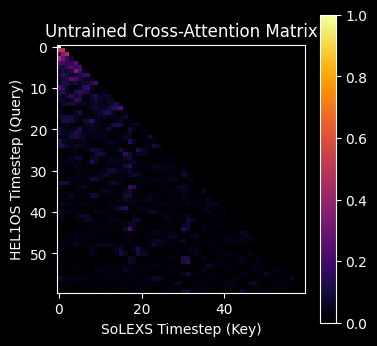

In [27]:
print(f"Cross-Attention Output Shape: {ca_out.shape}")
print(f"CTE (Attention) Weights Matrix Shape: {attn_weights.shape}")

# Visualizing a random untrained attention matrix
plt.figure(figsize=(4, 4))
plt.imshow(attn_weights[0, 0].numpy(), cmap='inferno') # Plotting the first head of the first batch item
plt.title("Untrained Cross-Attention Matrix")
plt.xlabel("SoLEXS Timestep (Key)")
plt.ylabel("HEL1OS Timestep (Query)")
plt.colorbar()
plt.show()


For each Hard X-ray time step, we obtain a 64-dimensional latent embedding that summarizes the most relevant information available to the model at that point, including the original Hard X-ray signal, the most relevant Soft X-ray responses, temporal context, and the learned relationships between them.

These latent encodings contains :
✓ Hard X-ray intensity

✓ Soft X-ray evolution

✓ Neupert delay

✓ Energy accumulation

✓ Temporal history

✓ Cross-modal relationships

✓ Flare morphology

✓ Learned physics patterns

In [28]:
# Moving to the Decision Prediction Head : 

#1- Shared trunk : First ill build one maser understanding -> Then I'll multiple questions .
    #Question 1 :Will flare occurs at next 1 hr ?
    #Question 2 : Will flare occur at next 6 hr ?
    #Question 3 : Will flare occur at next 12 hr ? 
    #Question 4 : Will flare occur at next 24 hr ? 

    # Why ? --> Beacuse if flare occurs within 1 hr ,it obviously affects the next 6 hrs too 

#2- Multi-Horization Head : Same Brain --> Different decisions 
    #Head 1 : Flare within 1 hr 
    #Head 2 : Flare within 6 hr 
    #Head 3 : Flare within 12 hr 
    #Head 4 : Flare within 24 hr 

#3- Temporal Attention Pooling : Imagine watching a movie ;
    #59 min: people are walking 
    #last 1 min : explosion 

    #Average Pooling : Nothing special 
    #Attention pooling :Not every second is important ,focus where the explosion starts 

# Reconstruction head : Along with the classification ,we also want model to understand the physics 
    #can you construct thye future soft x ray sequence 
    #Predicts future soft x-ray flux curve-> gets wrong -> backpropogation -> Transofrmer corrects it 


In [29]:
#Lets undertsand an example 
    #Imaginary : 
        #lets say we have Window 7-> 3 seconds-> 3 dimensional embeddings 

#1- Latent Embeddings : 
    #Second 1 : [2, 4, 3] -> Small solar activity 
    #Second 2 : [6, 5, 7]-> Begining of a flare 
    #Second 3 : [9, 8, 10]-> Peak flare 

#2-Temporal attention poolings :
    #Second 1 : gets attention_weigts of ->0.1
    #Second 2 : gets attention_weights of ->0.3
    #Second 3 : gets attention_weights of ->0.6

    #Compute weighted sum : 0.1*[2, 4, 3] + 0.3*[6, 5, 7] + 0.6*[9, 8, 10]
    #Summary embeddings = [7.4,6.7,8.4]

#3-Shared Trunk : 
    #[7.4,6.7,8.4]--> layer_norm->Dense+GELU->Dropout->Dense->Residual -->[8.1,7.2,9.0]-->Master representation 

    #Head 1 : [8.1,7.2,9.0]--> Logit :3.8--> 0.978--> 97.8% chance within 1 hr 
    #Head 2 : [8.1,7.2,9.0]--> Logit:2.2--> 0.900--> 90.0% chance within 6 hr 
    #Head 3 : [8.1,7.2,9.0]--> Logit:1.0--> 0.732--> 73.2% chance within 12 hr 
    #Head 4 : [8.1,7.2,9.0]-->Logit: -0.40--> 0.40--> 40.0% chance within 24 hr 


#4-Reconstruction Head : 
    #second 1 -> predict 51
    #second 2-> predict 70 
    #second 3 -> predict 110

    #Ground truth : [50,72,108]

    #Prediction->Loss Function->backpropagation->gradients->Optimizer(Adam)->Update weights and Biases

In [30]:
class TemporalAttentionPooling(layers.Layer):
   
    def __init__(self, **kwargs):
        super(TemporalAttentionPooling, self).__init__(**kwargs)
        
    def build(self, input_shape):
        embed_dim = input_shape[-1]
        self.w1 = layers.Dense(embed_dim // 2, activation='tanh', name='pool_w1')
        self.w2 = layers.Dense(1, name='pool_w2')
        super(TemporalAttentionPooling, self).build(input_shape)
        
    def call(self, x):
        scores = self.w2(self.w1(x))
        weights = tf.nn.softmax(scores, axis=1)
        pooled = tf.reduce_sum(x * weights, axis=1)
        return pooled

In [31]:
class NC2AN_Model(Model):

    def __init__(
        self,
        embed_dim=64,
        num_heads=4,
        position_encoding_type="rope",
        pooling_type="attention",
        **kwargs
    ):
        super(NC2AN_Model, self).__init__(**kwargs)

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.position_encoding_type = position_encoding_type
        self.pooling_type = pooling_type

        # Temporal Encoders

        self.enc_hard = TemporalEncoder(embed_dim)
        self.enc_soft = TemporalEncoder(embed_dim)

        # Used only for sinusoidal positional encoding
        self.pos_encoder = PositionalEncoding(
            encoding_type=position_encoding_type
        )

        # Final Cross Attention Block

        self.cross_attn = FinalCrossAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            position_encoding_type=position_encoding_type
        )

        # Temporal Pooling

        if pooling_type == "attention":
            self.pool = TemporalAttentionPooling()
        else:
            self.pool = layers.GlobalAveragePooling1D()

        self.dropout = layers.Dropout(0.2)

        # Shared Trunk

        self.trunk_dense = layers.Dense(
            embed_dim,
            activation="gelu",
            kernel_regularizer=tf.keras.regularizers.l2(1e-4)
        )

        self.trunk_ln = layers.LayerNormalization(epsilon=1e-6)

        self.trunk_dropout = layers.Dropout(0.2)

        # Multi-Horizon Forecast Heads

        self.head_1h = layers.Dense(
            1,
            activation="sigmoid",
            name="head_1h"
        )

        self.head_6h = layers.Dense(
            1,
            activation="sigmoid",
            name="head_6h"
        )

        self.head_12h = layers.Dense(
            1,
            activation="sigmoid",
            name="head_12h"
        )

        self.head_24h = layers.Dense(
            1,
            activation="sigmoid",
            name="head_24h"
        )

        # Reconstruction Head

        self.reconstruct_head = layers.Dense(
            1,
            name="soft_reconstruction"
        )

    def call(self, inputs, training=False):

        hard_seq, soft_seq = inputs

        # Temporal Encoding

        h = self.enc_hard(hard_seq)
        s = self.enc_soft(soft_seq)

        # Apply Sinusoidal PE ONLY when requested
        # RoPE is applied internally inside FinalCrossAttention

        if self.position_encoding_type == "sinusoidal":
            h = self.pos_encoder(h)
            s = self.pos_encoder(s)

        # Cross Attention

        ca_out, attn_weights = self.cross_attn(
            h,
            s,
            training=training
        )

        # Sequence Reconstruction Head

        pred_soft_seq = tf.squeeze(
            self.reconstruct_head(ca_out),
            axis=-1
        )

        # Temporal Attention Pooling

        final_token = self.pool(ca_out)

        final_token = self.dropout(
            final_token,
            training=training
        )

        # Shared Trunk

        trunk_out = self.trunk_dense(final_token)
        trunk_out = self.trunk_ln(trunk_out)
        trunk_out = self.trunk_dropout(
            trunk_out,
            training=training
        )

        # Multi-Horizon Forecast Heads

        pred_1h = tf.squeeze(
            self.head_1h(trunk_out),
            axis=-1
        )

        pred_6h = tf.squeeze(
            self.head_6h(trunk_out),
            axis=-1
        )

        pred_12h = tf.squeeze(
            self.head_12h(trunk_out),
            axis=-1
        )

        pred_24h = tf.squeeze(
            self.head_24h(trunk_out),
            axis=-1
        )

        return (
            (
                pred_1h,
                pred_6h,
                pred_12h,
                pred_24h,
            ),
            pred_soft_seq,
            attn_weights,
        )

    def get_config(self):

        config = super().get_config()

        config.update({

            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "position_encoding_type": self.position_encoding_type,
            "pooling_type": self.pooling_type

        })

        return config

In [32]:
model = NC2AN_Model(position_encoding_type='rope', pooling_type='attention')

# Forward pass test
(preds_1h,
 preds_6h,
 preds_12h,
 preds_24h), pred_soft_seq, ctp_matrix = model(
    (
        hard_input,
        soft_input
    )
)
print(f"Forecast 1h Shape: {preds_1h.shape} -> [Batch]")
print(f"Reconstructed Sequence Shape: {pred_soft_seq.shape} -> [Batch, SeqLen]")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'temporal_encoder_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'temporal_encoder_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'rotary_cross_attention_1' (of type RotaryCrossAtten

Forecast 1h Shape: (32,) -> [Batch]
Reconstructed Sequence Shape: (32, 60) -> [Batch, SeqLen]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'nc2an__model', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [33]:
# ============================================================
# Neupert Physics Loss & NDI Engine
# ============================================================

# Concept :
# A normal AI only learns to predict correctly.
# NC²AN learns to predict correctly AND obey Solar Physics.

# Goal :
# Hard X-Ray  ----->  Energy Injection
#                      ↓
#              Plasma Heating
#                      ↓
#            Soft X-Ray increases

# Mathematical Rule :
# d(Soft X-Ray)/dt  ∝  Hard X-Ray
# Rate of increase of Soft-XRay should follow Hard-XRay.


# ============================================================
# Step 1 : Compute dSoft/dt
# ============================================================

# Soft Flux :
# [10,15,35,95,135]

# dSoft/dt :
# [5,20,60,40]


# ============================================================
# Step 2 : Rise Phase Masking
# ============================================================

# Neupert Physics only explains the Heating Phase.
# Cooling phase follows different plasma physics.
# Ignore cooling completely.

# Before :
# [10,30,50,20,-10,-15,-20]

# Apply :
# tf.nn.relu(dSoft_dt)

# After :
# [10,30,50,20,0,0,0]

# Computer Thinking :
# "Only compare during Heating.
# Ignore Cooling."


# ============================================================
# Step 3 : L2 Normalization
# ============================================================

# Problem :
# Hard X-Ray and dSoft/dt may have different magnitudes
# because
#
# dSoft/dt = k × Hard
#
# where k is an unknown physical constant.

# Example :

# Hard :
# [10,20,30]

# dSoft/dt :
# [20,40,60]

# They have identical trends,
# only different scales.

# Normalize both vectors.

# Hard :
# [0.27,0.53,0.80]

# dSoft/dt :
# [0.27,0.53,0.80]

# Computer Thinking :
# "Ignore magnitude.
# Compare only the physical trend."


# ============================================================
# Step 4 : Cosine Physics Loss
# ============================================================

# Compare the normalized vectors.

# Same direction
# ↓
# Low Physics Loss

# Different direction
# ↓
# High Physics Loss

# Goal :
# Force the Transformer to learn
# the Neupert Relationship.


# ============================================================
# Step 5 : Total Training Loss
# ============================================================

# Total Loss
#
# =
#
# Data Loss
# +
# λ × Physics Loss

# Computer Thinking :
# "Prediction must be correct.
# Physics must also be correct."


# ============================================================
# Step 6 : Neupert Deviation Index (NDI)
# ============================================================

# NDI =
#
# Physics Loss
# ------------------------
# Data Loss + ε

# Example :

# Data Loss = 0.20
# Physics Loss = 0.04

# NDI = 0.20

# Meaning :
# Physics violation
# is only
# 20%
# of prediction error.

# Another Example :

# Data Loss = 0.10
# Physics Loss = 0.80

# NDI = 8.0

# Meaning :
# Model predicts correctly
# but completely violates
# Solar Physics.


# ============================================================
# Computer's Thinking
# ============================================================

# "I'm not only learning
# to classify solar flares.

# I'm learning
# the actual physics
# behind them.

# If my prediction
# violates
# the Neupert Effect,

# punish me,

# update my Transformer,

# and make me learn
# real Solar Physics."

In [34]:
def compute_neupert_loss(pred_soft_flux, true_soft_flux, true_hard_flux, lambda_neupert=0.3):
   
    # 1. Data Loss (Standard MSE)
    loss_data = tf.reduce_mean(tf.square(pred_soft_flux - true_soft_flux))
    
    # 2. Physics Constraint (Neupert Effect: dS/dt ~ H)
    # Calculate finite difference derivative of predicted Soft X-ray
    d_soft_dt = pred_soft_flux[:, 1:] - pred_soft_flux[:, :-1]
    
    # Align Hard X-ray shape
    aligned_hard = true_hard_flux[:, 1:]
    
    # ISOLATE RISE PHASE: Relu clamp positive derivatives (ignore decay/cooling)
    d_soft_rise = tf.nn.relu(d_soft_dt)
    
    # Normalize vectors to the unit hypersphere. The MSE between unit vectors
    # measures cosine distance, which cancels out the scaling coefficient k in dS/dt = k * H(t).
    d_soft_norm = tf.math.l2_normalize(d_soft_rise + 1e-8, axis=1)
    hard_norm = tf.math.l2_normalize(aligned_hard + 1e-8, axis=1)
    
    loss_physics = tf.reduce_mean(tf.square(d_soft_norm - hard_norm))
    
    # 3. Total Loss
    total_loss = loss_data + (lambda_neupert * loss_physics)
    
    # Neupert Deviation Index (NDI) - tracks physics compliance
    ndi = loss_physics / (loss_data + 1e-8)
    
    return total_loss, loss_data, loss_physics, ndi

In [35]:
import os
import time

# Final NC²AN Training Pipeline

optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-3,
    clipnorm=1.0
)

bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)


@tf.function
def train_step(
    hard_in,
    soft_in,
    true_labels,
    true_soft_seq,
    true_hard_seq,
    lambda_neupert=0.3,
    loss_weight_scheduling="fixed"
):
    hard_in = tf.cast(hard_in, tf.float32)
    soft_in = tf.cast(soft_in, tf.float32)
    true_labels = tf.cast(true_labels, tf.float32)
    true_soft_seq = tf.cast(true_soft_seq, tf.float32)
    true_hard_seq = tf.cast(true_hard_seq, tf.float32)

    with tf.GradientTape() as tape:
        (
            preds_1h,
            preds_6h,
            preds_12h,
            preds_24h
        ), pred_soft_seq, attn = model(
            (hard_in, soft_in),
            training=True
        )

        loss_1h = bce(true_labels, preds_1h)
        loss_6h = bce(true_labels, preds_6h)
        loss_12h = bce(true_labels, preds_12h)
        loss_24h = bce(true_labels, preds_24h)

        loss_forecast = (
            loss_1h +
            loss_6h +
            loss_12h +
            loss_24h
        )

        if loss_weight_scheduling == "dynamic":
            avg_hs_ratio = tf.reduce_mean(
                soft_in[:, :, 1],
                axis=1
            )
            mean_hs = tf.reduce_mean(avg_hs_ratio)
            dynamic_lambda = (
                lambda_neupert *
                tf.minimum(1.0, mean_hs)
            )
        else:
            dynamic_lambda = lambda_neupert

        total_loss, l_data, l_phys, ndi = compute_neupert_loss(
            pred_soft_seq,
            true_soft_seq,
            true_hard_seq,
            lambda_neupert=dynamic_lambda
        )

        combined_loss = loss_forecast + total_loss

    gradients = tape.gradient(
        combined_loss,
        model.trainable_variables
    )
    optimizer.apply_gradients(
        zip(
            gradients,
            model.trainable_variables
        )
    )

    return (
        combined_loss,
        loss_forecast,
        l_data,
        l_phys,
        tf.reduce_mean(ndi)
    )


@tf.function
def val_step(
    hard_in,
    soft_in,
    true_labels,
    true_soft_seq,
    true_hard_seq,
    lambda_neupert=0.3,
    loss_weight_scheduling="fixed"
):
    hard_in = tf.cast(hard_in, tf.float32)
    soft_in = tf.cast(soft_in, tf.float32)
    true_labels = tf.cast(true_labels, tf.float32)
    true_soft_seq = tf.cast(true_soft_seq, tf.float32)
    true_hard_seq = tf.cast(true_hard_seq, tf.float32)

    (
        preds_1h,
        preds_6h,
        preds_12h,
        preds_24h
    ), pred_soft_seq, attn = model(
        (hard_in, soft_in),
        training=False
    )

    loss_1h = bce(true_labels, preds_1h)
    loss_6h = bce(true_labels, preds_6h)
    loss_12h = bce(true_labels, preds_12h)
    loss_24h = bce(true_labels, preds_24h)

    loss_forecast = (
        loss_1h +
        loss_6h +
        loss_12h +
        loss_24h
    )

    if loss_weight_scheduling == "dynamic":
        avg_hs_ratio = tf.reduce_mean(
            soft_in[:, :, 1],
            axis=1
        )
        mean_hs = tf.reduce_mean(avg_hs_ratio)
        dynamic_lambda = (
            lambda_neupert *
            tf.minimum(1.0, mean_hs)
        )
    else:
        dynamic_lambda = lambda_neupert

    total_loss, l_data, l_phys, ndi = compute_neupert_loss(
        pred_soft_seq,
        true_soft_seq,
        true_hard_seq,
        lambda_neupert=dynamic_lambda
    )

    combined_loss = loss_forecast + total_loss

    return (
        combined_loss,
        loss_forecast,
        l_data,
        l_phys,
        tf.reduce_mean(ndi)
    )


def run_epoch(dataset, training):
    step_fn = train_step if training else val_step

    sum_loss = 0.0
    sum_forecast = 0.0
    sum_data = 0.0
    sum_phys = 0.0
    sum_ndi = 0.0
    num_batches = 0

    for batch_x, batch_y in dataset:
        batch_x = tf.cast(batch_x, tf.float32)
        batch_y = tf.cast(batch_y, tf.float32)

        hard_input = batch_x[:, :, 0:1]
        soft_input = batch_x[:, :, 1:]
        true_soft_seq = batch_x[:, :, 1]
        true_hard_seq = batch_x[:, :, 0]
        true_labels = batch_y

        loss, l_forecast, l_data, l_phys, ndi = step_fn(
            hard_input,
            soft_input,
            true_labels,
            true_soft_seq,
            true_hard_seq
        )

        sum_loss += float(loss)
        sum_forecast += float(l_forecast)
        sum_data += float(l_data)
        sum_phys += float(l_phys)
        sum_ndi += float(ndi)
        num_batches += 1

    return (
        sum_loss / num_batches,
        sum_forecast / num_batches,
        sum_data / num_batches,
        sum_phys / num_batches,
        sum_ndi / num_batches
    )


# Training Configuration

EPOCHS = 200
EARLY_STOP_PATIENCE = 20
LR_PATIENCE = 7
LR_FACTOR = 0.5
MIN_LR = 1e-6

CHECKPOINT_DIR = "/kaggle/working"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
CHECKPOINT_PATH = f"{CHECKPOINT_DIR}/best_nc2an_model.weights.h5"

best_val_loss = float("inf")
best_epoch = -1
es_wait = 0
lr_wait = 0

history = {
    "train_loss": [], "val_loss": [],
    "train_forecast": [], "val_forecast": [],
    "train_data": [], "val_data": [],
    "train_phys": [], "val_phys": [],
    "train_ndi": [], "val_ndi": [],
    "lr": []
}

print("=" * 70)
print("Starting NC²AN Training...")
print("=" * 70)

training_start_time = time.time()

for epoch in range(EPOCHS):
    epoch_start_time = time.time()

    train_loss, train_forecast, train_data, train_phys, train_ndi = run_epoch(
        train_dataset, training=True
    )

    val_loss, val_forecast, val_data, val_phys, val_ndi = run_epoch(
        val_dataset, training=False
    )

    current_lr = float(optimizer.learning_rate.numpy())

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_forecast"].append(train_forecast)
    history["val_forecast"].append(val_forecast)
    history["train_data"].append(train_data)
    history["val_data"].append(val_data)
    history["train_phys"].append(train_phys)
    history["val_phys"].append(val_phys)
    history["train_ndi"].append(train_ndi)
    history["val_ndi"].append(val_ndi)
    history["lr"].append(current_lr)

    epoch_time = time.time() - epoch_start_time

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train NDI: {train_ndi:.4f} | "
        f"Val NDI: {val_ndi:.4f} | "
        f"LR: {current_lr:.2e} | "
        f"{epoch_time:.1f}s"
    )
    print(
        f"          Forecast(T/V): {train_forecast:.4f}/{val_forecast:.4f} | "
        f"Data(T/V): {train_data:.4f}/{val_data:.4f} | "
        f"Physics(T/V): {train_phys:.4f}/{val_phys:.4f}"
    )

    if val_loss < best_val_loss:
        improvement = best_val_loss - val_loss
        best_val_loss = val_loss
        best_epoch = epoch + 1
        es_wait = 0
        lr_wait = 0
        model.save_weights(CHECKPOINT_PATH)
        print(
            f"           Val loss improved by {improvement:.4f} "
            f"-> saved best model to {CHECKPOINT_PATH}"
        )
    else:
        es_wait += 1
        lr_wait += 1

    if lr_wait >= LR_PATIENCE:
        new_lr = max(current_lr * LR_FACTOR, MIN_LR)
        if new_lr < current_lr:
            optimizer.learning_rate.assign(new_lr)
            print(
                f"           ReduceLROnPlateau: "
                f"LR reduced {current_lr:.2e} -> {new_lr:.2e}"
            )
        lr_wait = 0

    if es_wait >= EARLY_STOP_PATIENCE:
        print(
            f"           EarlyStopping triggered "
            f"(no val improvement for {EARLY_STOP_PATIENCE} epochs)"
        )
        break

total_time = time.time() - training_start_time

model.load_weights(CHECKPOINT_PATH)

print("=" * 70)
print("Training Finished Successfully.")
print("=" * 70)
print(f"Total epochs run      : {epoch + 1}/{EPOCHS}")
print(f"Best epoch             : {best_epoch}")
print(f"Best validation loss   : {best_val_loss:.4f}")
print(
    f"Final NDI (train/val)  : "
    f"{history['train_ndi'][-1]:.4f} / {history['val_ndi'][-1]:.4f}"
)
print(f"Final learning rate    : {history['lr'][-1]:.2e}")
print(f"Total training time    : {total_time/60:.1f} min")
print(f"Best model weights restored from: {CHECKPOINT_PATH}")
print("=" * 70)

Starting NC²AN Training...
Epoch 1/200 | Train Loss: 0.4807 | Val Loss: 0.4434 | Train NDI: 0.1193 | Val NDI: 0.1447 | LR: 1.00e-03 | 25.1s
          Forecast(T/V): 0.2811/0.3004 | Data(T/V): 0.1954/0.1391 | Physics(T/V): 0.0142/0.0129
           Val loss improved by inf -> saved best model to /kaggle/working/best_nc2an_model.weights.h5
Epoch 2/200 | Train Loss: 0.2053 | Val Loss: 0.6535 | Train NDI: 0.3164 | Val NDI: 0.1536 | LR: 1.00e-03 | 6.6s
          Forecast(T/V): 0.1321/0.4340 | Data(T/V): 0.0676/0.2133 | Physics(T/V): 0.0186/0.0208
Epoch 3/200 | Train Loss: 0.1720 | Val Loss: 0.4417 | Train NDI: 0.6150 | Val NDI: 0.4619 | LR: 1.00e-03 | 6.6s
          Forecast(T/V): 0.1155/0.2633 | Data(T/V): 0.0494/0.1728 | Physics(T/V): 0.0236/0.0189
           Val loss improved by 0.0017 -> saved best model to /kaggle/working/best_nc2an_model.weights.h5
Epoch 4/200 | Train Loss: 0.1393 | Val Loss: 0.4191 | Train NDI: 0.9662 | Val NDI: 0.8063 | LR: 1.00e-03 | 6.6s
          Forecast(T/V): 0.

In [36]:
                #----How Confident are you ? ----#

# Scenario 1 : Flare-> 97% confidance-> Very High 
#Scenario 2 : Flare -> 97% confidance-> Very slow(Be careful)

#Method : Monte Carlo Droput 
#Soltution : randoly turning off the Neurons 
#Why?: If i solve this problem 100 times ,do i always reach the same answer ?->Averaging

#Yes --> Confidance very high
#No---> Confidance Low 

In [37]:
# ============================================================
# MC Dropout Uncertainty Module
# ============================================================

# Concept :
# Prediction alone is not enough.
# AI must also tell how confident it is.

# Goal :
# Operational Space Weather Forecasting
# should provide
# Prediction + Confidence Score.


# Monte Carlo Dropout :
# Keep Dropout ON even during Inference.
# Run the same input multiple times.

# Example :

# Run 1 -> 94%
# Run 2 -> 96%
# Run 3 -> 95%
# Run 4 -> 93%
# Run 5 -> 96%

# Mean Prediction :
# 94.8%

# Standard Deviation :
# 1%

# Computer Thinking :
# "All predictions are similar.
# I'm highly confident."


# Another Example :

# Run 1 -> 30%
# Run 2 -> 90%
# Run 3 -> 55%
# Run 4 -> 70%
# Run 5 -> 20%

# Mean Prediction :
# 53%

# Standard Deviation :
# 28%

# Computer Thinking :
# "Every run gives a different answer.
# My confidence is low."


# ============================================================
# EMA Smoothing on NDI
# ============================================================

# Goal :
# Prevent noisy NDI spikes
# from triggering false satellite alerts.

# Before :
# [0.12,0.15,0.13,0.80,0.14,0.16]

# After EMA :
# [0.12,0.13,0.14,0.25,0.21,0.19]

# Computer Thinking :
# "Ignore sudden noisy spikes.
# Trigger alerts only when
# the trend is consistently abnormal."


# ============================================================
# Final Output
# ============================================================

# Flare Probability
# +
# Confidence Interval
# +
# Smoothed NDI
# =
# Reliable Operational Forecast

In [38]:
def mc_dropout_inference(model, hard_input, soft_input, n_passes=20):
    
    predictions_1h = []
    
    for _ in range(n_passes):
        (p1h, _, _, _), _, _ = model((hard_input, soft_input), training=True)
        predictions_1h.append(p1h.numpy())
            
    predictions_1h = np.stack(predictions_1h, axis=0) # Shape: [N_passes, Batch]
    
    mean_pred = np.mean(predictions_1h, axis=0)
    std_pred = np.std(predictions_1h, axis=0)
    
    return mean_pred, std_pred

def smooth_ndi(ndi_values, alpha=0.1):
    
    smoothed = np.zeros_like(ndi_values)
    smoothed[0] = ndi_values[0]
    for t in range(1, len(ndi_values)):
        smoothed[t] = alpha * ndi_values[t] + (1 - alpha) * smoothed[t-1]
    return smoothed

# Run MC Dropout
mean_forecast, std_forecast = mc_dropout_inference(
    model,
    hard_input,
    soft_input
)

print(f"Prediction for item 0: {mean_forecast[0]*100:.2f}% probability ± {std_forecast[0]*100:.2f}% (1-sigma)")


Prediction for item 0: 0.02% probability ± 0.03% (1-sigma)


In [51]:
#NC2AN Hyperparameter Search Engine :
import itertools, random, gc, time, os, json
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import f1_score, roc_auc_score
 
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)
 
# ── Search space (edit freely) ───────────────────────────────────
SEARCH_SPACE = {
    "embed_dim"              : [64, 96, 128],
    "num_heads"              : [4, 8],
    "dropout_rate"           : [0.2, 0.3, 0.4],
    "learning_rate"          : [1e-3, 5e-4, 2e-4],
    "lambda_neupert"         : [0.2, 0.3, 0.5],
    "pooling_type"           : ["attention", "average"],
    "position_encoding_type" : ["rope"] #Right now only RoPE,
}
# Full grid size: 3×2×3×3×3×2×2 = 648 combinations
 
# ── Search strategy ──────────────────────────────────────────────
SEARCH_MODE    = "random"                     # "random" | "grid"
N_TRIALS       = 10                           # trials for random mode
SEARCH_EPOCHS  = 10                           # epochs per trial
ES_PATIENCE    = 5                            # early-stop patience
LR_PATIENCE    = 4                            # ReduceLR patience
LR_FACTOR      = 0.5
MIN_LR         = 1e-6
CHECKPOINT_DIR = "/kaggle/working/nc2an_hp_search"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
 
print(f"✅  NC²AN HP Search | mode={SEARCH_MODE} "
      f"| trials={N_TRIALS} | epochs/trial={SEARCH_EPOCHS}")
print(f"    Checkpoints → {CHECKPOINT_DIR}")
 
 

✅  NC²AN HP Search | mode=random | trials=10 | epochs/trial=10
    Checkpoints → /kaggle/working/nc2an_hp_search


In [52]:
#Core Engine :
class FixedPositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, max_len=5000, encoding_type="sinusoidal", **kwargs):
        super().__init__(**kwargs)
        self.max_len       = max_len
        self.encoding_type = encoding_type
        self._pe           = None                  # built lazily
 
    def build(self, input_shape):
        d = int(input_shape[-1])                   # actual embed_dim
        if self.encoding_type == "sinusoidal":
            pe  = np.zeros((self.max_len, d), dtype=np.float32)
            pos = np.arange(self.max_len, dtype=np.float32)[:, None]
            div = np.exp(
                np.arange(0, d, 2, dtype=np.float32) * -(np.log(10000.0) / d)
            )
            pe[:, 0::2] = np.sin(pos * div)
            # floor(d/2) cos terms – safe for both even and odd d
            pe[:, 1::2] = np.cos(pos * div[: d // 2])
            self._pe = tf.constant(pe[None], dtype=tf.float32)  # [1, T, d]
        super().build(input_shape)
 
    def call(self, x):
        if self.encoding_type == "sinusoidal" and self._pe is not None:
            return x + self._pe[:, : tf.shape(x)[1], :]
        return x   # "rope" → handled inside FinalCrossAttention
 
 

In [53]:
class NC2AN_SearchModel(tf.keras.Model):
    def __init__(
        self,
        embed_dim              = 64,
        num_heads              = 4,
        dropout_rate           = 0.2,
        position_encoding_type = "rope",
        pooling_type           = "attention",
        **kwargs,
    ):
        super().__init__(**kwargs)
        assert embed_dim % num_heads == 0, (
            f"embed_dim={embed_dim} must be divisible by num_heads={num_heads}"
        )
        self.embed_dim              = embed_dim
        self.num_heads              = num_heads
        self.dropout_rate           = dropout_rate
        self.position_encoding_type = position_encoding_type
        self.pooling_type           = pooling_type
 
        # Temporal CNN encoders (reused from global scope)
        self.enc_hard = TemporalEncoder(embed_dim)
        self.enc_soft = TemporalEncoder(embed_dim)
 
        # Bug-fixed positional encoding
        self.pos_encoder = FixedPositionalEncoding(
            encoding_type=position_encoding_type
        )
 
        # Cross-attention block with parameterised dropout
        self.cross_attn = FinalCrossAttention(
            embed_dim              = embed_dim,
            num_heads              = num_heads,
            dropout_rate           = dropout_rate,   # ← was hardcoded 0.1
            position_encoding_type = position_encoding_type,
        )
 
        # Temporal pooling
        if pooling_type == "attention":
            self.pool = TemporalAttentionPooling()
        else:
            self.pool = tf.keras.layers.GlobalAveragePooling1D()
 
        # Shared trunk
        self.seq_drop    = tf.keras.layers.Dropout(dropout_rate)
        self.trunk_dense = tf.keras.layers.Dense(
            embed_dim, activation="gelu",
            kernel_regularizer=tf.keras.regularizers.l2(1e-4),
        )
        self.trunk_ln    = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.trunk_drop  = tf.keras.layers.Dropout(dropout_rate)
 
        # Multi-horizon heads
        self.head_1h  = tf.keras.layers.Dense(1, activation="sigmoid", name="h_1h")
        self.head_6h  = tf.keras.layers.Dense(1, activation="sigmoid", name="h_6h")
        self.head_12h = tf.keras.layers.Dense(1, activation="sigmoid", name="h_12h")
        self.head_24h = tf.keras.layers.Dense(1, activation="sigmoid", name="h_24h")
 
        # Physics reconstruction head
        self.recon_head = tf.keras.layers.Dense(1, name="soft_recon")
 
    def call(self, inputs, training=False):
        hard_seq, soft_seq = inputs
 
        h = self.enc_hard(hard_seq)
        s = self.enc_soft(soft_seq)
 
        # Sinusoidal PE applied before cross-attention;
        # RoPE is applied inside FinalCrossAttention itself.
        if self.position_encoding_type == "sinusoidal":
            h = self.pos_encoder(h)
            s = self.pos_encoder(s)
 
        ca_out, attn_weights = self.cross_attn(h, s, training=training)
 
        # Physics: reconstruct soft X-ray sequence
        pred_soft = tf.squeeze(self.recon_head(ca_out), axis=-1)
 
        # Pooling → trunk → heads
        tok = self.pool(ca_out)
        tok = self.seq_drop(tok, training=training)
        tok = self.trunk_dense(tok)
        tok = self.trunk_ln(tok)
        tok = self.trunk_drop(tok, training=training)
 
        p1h  = tf.squeeze(self.head_1h(tok),  axis=-1)
        p6h  = tf.squeeze(self.head_6h(tok),  axis=-1)
        p12h = tf.squeeze(self.head_12h(tok), axis=-1)
        p24h = tf.squeeze(self.head_24h(tok), axis=-1)
 
        return (p1h, p6h, p12h, p24h), pred_soft, attn_weights
 
    def get_config(self):
        return {
            **super().get_config(),
            "embed_dim"              : self.embed_dim,
            "num_heads"              : self.num_heads,
            "dropout_rate"           : self.dropout_rate,
            "position_encoding_type" : self.position_encoding_type,
            "pooling_type"           : self.pooling_type,
        }
 

In [42]:
class NC2ANTrainer:
    def __init__(self, model, optimizer, lambda_neupert=0.3):
        self.model          = model
        self.optimizer      = optimizer
        self.lambda_neupert = float(lambda_neupert)
        self._bce           = tf.keras.losses.BinaryCrossentropy(from_logits=False)
 
    # forward pass
    def _fwd(self, bx, by, training):
        bx     = tf.cast(bx, tf.float32)
        by     = tf.cast(by, tf.float32)
 
        hard   = bx[:, :, 0:1]    # [B, T, 1]  – HEL1OS
        soft   = bx[:, :, 1:]     # [B, T, 4]  – SoLEXS features
        t_soft = bx[:, :, 1]      # [B, T]     – raw soft flux (feat 1)
        t_hard = bx[:, :, 0]      # [B, T]     – raw hard flux (feat 0)
 
        (p1h, p6h, p12h, p24h), pred_soft, _ = self.model(
            (hard, soft), training=training
        )
 
        # Multi-horizon classification loss
        l_fore = (
            self._bce(by, p1h)  + self._bce(by, p6h) +
            self._bce(by, p12h) + self._bce(by, p24h)
        )
 
        # Neupert physics loss  (reuses globally-defined function)
        total_loss, l_data, l_phys, ndi = compute_neupert_loss(
            pred_soft, t_soft, t_hard, self.lambda_neupert
        )
 
        combined = l_fore + total_loss
        return combined, l_fore, l_data, l_phys, tf.reduce_mean(ndi)
 
    # training step
    def train_step(self, bx, by):
        with tf.GradientTape() as tape:
            results = self._fwd(bx, by, training=True)
        grads = tape.gradient(results[0], self.model.trainable_variables)
        self.optimizer.apply_gradients(
            zip(grads, self.model.trainable_variables)
        )
        return tuple(float(r) for r in results)   # 5 Python floats
 
    #  validation step 
    def val_step(self, bx, by):
        return tuple(float(r) for r in self._fwd(bx, by, training=False))
 
    #  epoch loop 
    def run_epoch(self, dataset, training):
        fn  = self.train_step if training else self.val_step
        acc = np.zeros(5, dtype=np.float64)
        n   = 0
        for bx, by in dataset:
            acc += fn(bx, by)
            n   += 1
        return acc / max(n, 1)

In [54]:
def _clf_metrics(model, val_ds):
    """Collect 1h-head predictions → F1 + ROC-AUC on val set."""
    ps, ls = [], []
    for bx, by in val_ds:
        bx = tf.cast(bx, tf.float32)
        (p1h, _, _, _), _, _ = model(
            (bx[:, :, 0:1], bx[:, :, 1:]), training=False
        )
        ps.extend(p1h.numpy().ravel().tolist())
        ls.extend(by.numpy().ravel().tolist())
 
    y_score = np.array(ps, dtype=np.float32)
    y_true  = (np.array(ls) > 0.5).astype(int)
    y_pred  = (y_score > 0.5).astype(int)
 
    f1 = float(f1_score(y_true, y_pred, zero_division=0))
    try:
        auc = float(roc_auc_score(y_true, y_score))
    except ValueError:
        auc = float("nan")
    return f1, auc
 
 
# 5. Single-trial runner
def run_trial(cfg, trial_id, train_ds, val_ds):
    tag = (
        f"emb={cfg['embed_dim']} hds={cfg['num_heads']} "
        f"dr={cfg['dropout_rate']} lr={cfg['learning_rate']:.0e} "
        f"λ={cfg['lambda_neupert']} "
        f"pool={cfg['pooling_type'][:3]} "
        f"pe={cfg['position_encoding_type'][:3]}"
    )
    print(f"\n  {'─'*65}")
    print(f"  Trial {trial_id:02d} │ {tag}")
    print(f"  {'─'*65}")
 
    # Build
    m   = NC2AN_SearchModel(
        embed_dim              = cfg["embed_dim"],
        num_heads              = cfg["num_heads"],
        dropout_rate           = cfg["dropout_rate"],
        position_encoding_type = cfg["position_encoding_type"],
        pooling_type           = cfg["pooling_type"],
    )
    opt = tf.keras.optimizers.Adam(
        learning_rate=cfg["learning_rate"], clipnorm=1.0
    )
    tr  = NC2ANTrainer(m, opt, cfg["lambda_neupert"])
 
    # Warm-up: build all weights before first save_weights call
    for bx, _ in train_ds.take(1):
        bx = tf.cast(bx, tf.float32)
        _  = m((bx[:, :, 0:1], bx[:, :, 1:]), training=False)
 
    ckpt   = f"{CHECKPOINT_DIR}/trial_{trial_id:02d}.weights.h5"
    best   = float("inf")
    best_ep = 0
    es_w   = 0
    lr_w   = 0
 
    #  Train 
    for ep in range(SEARCH_EPOCHS):
        t_m = tr.run_epoch(train_ds, training=True)
        v_m = tr.run_epoch(val_ds,   training=False)
 
        v_loss = v_m[0]
 
        if np.isfinite(v_loss) and v_loss < best:
            delta   = best - v_loss
            best    = v_loss
            best_ep = ep + 1
            es_w    = 0
            lr_w    = 0
            m.save_weights(ckpt)
            note = f"  ✓ best={best:.4f} (↓{delta:.4f})"
        else:
            es_w += 1
            lr_w += 1
            note  = f"  es={es_w}/{ES_PATIENCE}"
 
        print(
            f"    Ep{ep+1:02d}/{SEARCH_EPOCHS} "
            f"T:{t_m[0]:.4f} V:{v_loss:.4f} │ "
            f"Fore:{v_m[1]:.4f} Data:{v_m[2]:.4f} "
            f"Phys:{v_m[3]:.4f} NDI:{v_m[4]:.4f}{note}"
        )
 
        # ReduceLR
        if lr_w >= LR_PATIENCE:
            cur_lr = float(opt.learning_rate.numpy())
            new_lr = max(cur_lr * LR_FACTOR, MIN_LR)
            if new_lr < cur_lr:
                opt.learning_rate.assign(new_lr)
                print(f"    ReduceLR : {cur_lr:.1e} → {new_lr:.1e}")
            lr_w = 0
 
        # EarlyStopping
        if es_w >= ES_PATIENCE:
            print(f"    EarlyStopping at epoch {ep+1}")
            break
 
    # Evaluate at best checkpoint 
    m.load_weights(ckpt)
    v_final     = tr.run_epoch(val_ds, training=False)
    f1, auc     = _clf_metrics(m, val_ds)
 
    result = dict(
        trial_id          = trial_id,
        config            = cfg,
        best_val_loss     = float(best),
        val_forecast_loss = float(v_final[1]),
        val_data_loss     = float(v_final[2]),
        val_physics_loss  = float(v_final[3]),
        val_ndi           = float(v_final[4]),
        val_f1            = f1,
        val_auc           = auc,
        best_epoch        = best_ep,
        ckpt_path         = ckpt,
    )
 
    # Cleanup (disk checkpoint is preserved) 
    del m, tr, opt
    gc.collect()
    return result
 
 
# 6. Config samplers
def _grid(space):
    keys, vals = zip(*space.items())
    return [dict(zip(keys, combo)) for combo in itertools.product(*vals)]
 
def _random(space, n, seed=42):
    all_cfgs = _grid(space)
    return random.Random(seed).sample(all_cfgs, min(n, len(all_cfgs)))
 
 
# 7. Leaderboard DataFrame helper
def _make_leaderboard(ranked):
    medals = {1: "🥇", 2: "🥈", 3: "🥉"}
    rows   = []
    for rank, r in enumerate(ranked, 1):
        c = r["config"]
        rows.append({
            "Rank"    : rank,
            ""        : medals.get(rank, ""),
            "Embed"   : c["embed_dim"],
            "Heads"   : c["num_heads"],
            "Dropout" : c["dropout_rate"],
            "LR"      : f"{c['learning_rate']:.0e}",
            "λ_npt"   : c["lambda_neupert"],
            "Pool"    : c["pooling_type"][:3],
            "PE"      : c["position_encoding_type"][:3],
            "Val Loss": round(r["best_val_loss"],     4),
            "ForeLoss": round(r["val_forecast_loss"], 4),
            "PhysLoss": round(r["val_physics_loss"],  4),
            "NDI"     : round(r["val_ndi"],           4),
            "F1"      : round(r["val_f1"],            4),
            "ROC-AUC" : round(r["val_auc"],           4),
            "BestEp"  : r["best_epoch"],
            "Trial"   : r["trial_id"],
        })
    return pd.DataFrame(rows).set_index("Rank")
 
 
print("  NC²AN HP Search Engine ready.  Run Cell C to begin the search.")

  NC²AN HP Search Engine ready.  Run Cell C to begin the search.


In [ ]:
#Engine Execute :
if SEARCH_MODE == "grid":
    trials = _grid(SEARCH_SPACE)
    print(f"Mode : Grid Search → {len(trials)} combinations")
else:
    trials = _random(SEARCH_SPACE, N_TRIALS)
    print(f"Mode : Random Search → {len(trials)} trials (pool=648, seed=42)")
 
print(f"Epochs/trial : {SEARCH_EPOCHS}  │  ES patience : {ES_PATIENCE}\n")
 
#  Execute 
all_results = []
t0          = time.time()
 
for idx, cfg in enumerate(trials, 1):
    try:
        r = run_trial(cfg, idx, train_dataset, val_dataset)
        all_results.append(r)
    except Exception as e:
        print(f"\n  ⚠  Trial {idx} FAILED: {e}")
        continue
 
    # ── Live snapshot (top-5 after each trial) ──
    ranked  = sorted(all_results, key=lambda x: x["best_val_loss"])
    elapsed = (time.time() - t0) / 60
    print(f"\n  📊 Snapshot [{idx}/{len(trials)}] — {elapsed:.1f} min elapsed")
    snap_df = _make_leaderboard(ranked[:5])
    display(snap_df)
 
# Final leaderboard
ranked       = sorted(all_results, key=lambda x: x["best_val_loss"])
total_time   = (time.time() - t0) / 60
 
print(f"\n{'═'*70}")
print(f"  NC²AN HYPERPARAMETER SEARCH COMPLETE")
print(f"  {len(all_results)} trials  │  {total_time:.1f} min total")
print(f"{'═'*70}\n")
 
lb_df = _make_leaderboard(ranked)
display(lb_df)
 
# Save leaderboard JSON 
lb_json = f"{CHECKPOINT_DIR}/leaderboard.json"
with open(lb_json, "w") as f:
    json.dump(ranked, f, indent=2, default=str)
print(f"\n  📁 Saved → {lb_json}")

Mode : Random Search → 10 trials (pool=648, seed=42)
Epochs/trial : 10  │  ES patience : 5


  ─────────────────────────────────────────────────────────────────
  Trial 01 │ emb=64 hds=8 dr=0.2 lr=1e-03 λ=0.3 pool=ave pe=rop
  ─────────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'temporal_encoder_18', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'temporal_encoder_19', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'rotary_cross_attention_9' (of type RotaryCrossAtt

    Ep01/10 T:0.4253 V:0.4771 │ Fore:0.3227 Data:0.1518 Phys:0.0085 NDI:0.0715  ✓ best=0.4771 (↓inf)
    Ep02/10 T:0.1943 V:0.4281 │ Fore:0.3459 Data:0.0769 Phys:0.0174 NDI:0.3906  ✓ best=0.4281 (↓0.0490)
    Ep03/10 T:0.1656 V:0.3165 │ Fore:0.2474 Data:0.0641 Phys:0.0166 NDI:0.5993  ✓ best=0.3165 (↓0.1116)
    Ep04/10 T:0.1433 V:0.5621 │ Fore:0.4747 Data:0.0812 Phys:0.0206 NDI:0.6910  es=1/5
    Ep05/10 T:0.1318 V:3.2502 │ Fore:2.7724 Data:0.4704 Phys:0.0248 NDI:0.2406  es=2/5
    Ep06/10 T:0.1331 V:0.4854 │ Fore:0.3694 Data:0.1094 Phys:0.0222 NDI:0.7704  es=3/5
    Ep07/10 T:0.1158 V:0.3090 │ Fore:0.2535 Data:0.0489 Phys:0.0224 NDI:1.0996  ✓ best=0.3090 (↓0.0074)
    Ep08/10 T:0.1175 V:0.3779 │ Fore:0.3324 Data:0.0388 Phys:0.0225 NDI:2.0218  es=1/5
    Ep09/10 T:0.0967 V:0.4606 │ Fore:0.3525 Data:0.1011 Phys:0.0232 NDI:0.6140  es=2/5
    Ep10/10 T:0.0985 V:0.3611 │ Fore:0.2552 Data:0.0991 Phys:0.0224 NDI:0.8665  es=3/5

  📊 Snapshot [1/10] — 21.3 min elapsed


,,Embed,Heads,Dropout,LR,λ_npt,Pool,PE,Val Loss,ForeLoss,PhysLoss,NDI,F1,ROC-AUC,BestEp,Trial
Rank,,,,,,,,,,,,,,,,
1,🥇,64,8,0.2,1e-03,0.3,ave,rop,0.309,0.2535,0.0224,1.0996,0.9177,0.9955,7,1



  ─────────────────────────────────────────────────────────────────
  Trial 02 │ emb=64 hds=4 dr=0.2 lr=2e-04 λ=0.2 pool=att pe=rop
  ─────────────────────────────────────────────────────────────────


...

    Ep01/10 T:0.5230 V:0.5758 │ Fore:0.3984 Data:0.1745 Phys:0.0096 NDI:0.1129  ✓ best=0.5758 (↓inf)
    Ep02/10 T:0.1980 V:0.3649 │ Fore:0.2845 Data:0.0750 Phys:0.0182 NDI:0.3622  ✓ best=0.3649 (↓0.2109)
    Ep03/10 T:0.1442 V:0.4641 │ Fore:0.3809 Data:0.0769 Phys:0.0210 NDI:0.5204  es=1/5
    Ep04/10 T:0.1471 V:0.5008 │ Fore:0.4240 Data:0.0700 Phys:0.0224 NDI:0.5491  es=2/5
    Ep05/10 T:0.1344 V:0.3906 │ Fore:0.3109 Data:0.0732 Phys:0.0217 NDI:1.0301  es=3/5
    Ep06/10 T:0.1208 V:0.4936 │ Fore:0.2799 Data:0.2069 Phys:0.0228 NDI:0.4387  es=4/5
    ReduceLR : 5.0e-04 → 2.5e-04
    Ep07/10 T:0.0980 V:0.3992 │ Fore:0.2942 Data:0.0980 Phys:0.0231 NDI:1.2778  es=5/5
    EarlyStopping at epoch 7

  📊 Snapshot [8/10] — 163.8 min elapsed


,,Embed,Heads,Dropout,LR,λ_npt,Pool,PE,Val Loss,ForeLoss,PhysLoss,NDI,F1,ROC-AUC,BestEp,Trial
Rank,,,,,,,,,,,,,,,,
1,🥇,96,4,0.2,2e-04,0.5,ave,rop,0.2945,0.2440,0.0162,0.5899,0.9168,0.9963,6,4
2,🥈,96,4,0.2,5e-04,0.2,att,rop,0.2990,0.2230,0.0248,1.3440,0.9119,0.9963,9,5
3,🥉,64,4,0.2,2e-04,0.2,att,rop,0.2998,0.2562,0.0243,1.0003,0.9019,0.9958,9,2
4,,64,8,0.2,1e-03,0.3,ave,rop,0.3090,0.2535,0.0224,1.0996,0.9177,0.9955,7,1
5,,64,8,0.2,2e-04,0.5,ave,rop,0.3217,0.2375,0.0171,0.4103,0.9077,0.9961,10,6



  ─────────────────────────────────────────────────────────────────
  Trial 09 │ emb=64 hds=4 dr=0.4 lr=5e-04 λ=0.3 pool=att pe=rop
  ─────────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'temporal_encoder_34', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'temporal_encoder_35', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'rotary_cross_attention_17' (of type RotaryCrossAt

    Ep01/10 T:0.5732 V:0.4581 │ Fore:0.3037 Data:0.1489 Phys:0.0183 NDI:0.1865  ✓ best=0.4581 (↓inf)


In [57]:
#Did this beacuse my training gets freezed after the trial 8 : GPU issue 
#So saved the one which is in the top of Leaderboard 

import os
import json
import pandas as pd

# Get Best Trial

best = ranked[0]
bc = best["config"]

# Print Best Configuration

print(f"\n{'═'*70}")
print(f"                 🥇 BEST NC²AN CONFIGURATION")
print(f"{'═'*70}")

print(f"{'Trial ID':<30}: {best['trial_id']}")
print(f"{'Embed Dimension':<30}: {bc['embed_dim']}")
print(f"{'Number of Heads':<30}: {bc['num_heads']}")
print(f"{'Dropout Rate':<30}: {bc['dropout_rate']}")
print(f"{'Learning Rate':<30}: {bc['learning_rate']:.0e}")
print(f"{'Neupert Lambda':<30}: {bc['lambda_neupert']}")
print(f"{'Pooling Type':<30}: {bc['pooling_type']}")
print(f"{'Position Encoding':<30}: {bc['position_encoding_type']}")

print(f"\n{'─'*70}")

print(f"{'Validation Loss':<30}: {best['best_val_loss']:.4f}")
print(f"{'Forecast Loss':<30}: {best['val_forecast_loss']:.4f}")
print(f"{'Physics Loss':<30}: {best['val_physics_loss']:.4f}")
print(f"{'Neupert Deviation Index':<30}: {best['val_ndi']:.4f}")
print(f"{'F1 Score':<30}: {best['val_f1']:.4f}")
print(f"{'ROC-AUC':<30}: {best['val_auc']:.4f}")
print(f"{'Best Epoch':<30}: {best['best_epoch']}")

print(f"{'═'*70}")

# Model Constructor Snippet

best_cfg_str = (
    f"embed_dim={bc['embed_dim']}, "
    f"num_heads={bc['num_heads']}, "
    f"dropout_rate={bc['dropout_rate']}, "
    f"position_encoding_type='{bc['position_encoding_type']}', "
    f"pooling_type='{bc['pooling_type']}'"
)

print("\nRecommended Model Constructor:\n")
print(f"model = NC2AN_Model({best_cfg_str})")

# Save Best Configuration

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

best_config_path = os.path.join(
    CHECKPOINT_DIR,
    "best_config.json"
)

with open(best_config_path, "w") as f:
    json.dump(best, f, indent=4, default=str)

# Save Leaderboard

leaderboard_df = pd.DataFrame(ranked)

leaderboard_csv = os.path.join(
    CHECKPOINT_DIR,
    "leaderboard.csv"
)

leaderboard_json = os.path.join(
    CHECKPOINT_DIR,
    "leaderboard.json"
)

leaderboard_df.to_csv(
    leaderboard_csv,
    index=False
)

with open(leaderboard_json, "w") as f:
    json.dump(ranked, f, indent=4, default=str)

# Save Human Readable Report

report_path = os.path.join(
    CHECKPOINT_DIR,
    "best_configuration_report.txt"
)

with open(report_path, "w") as f:

    f.write("NC²AN Hyperparameter Search\n")
    f.write("=" * 70 + "\n\n")

    f.write(f"Trial ID                : {best['trial_id']}\n")
    f.write(f"Embed Dimension         : {bc['embed_dim']}\n")
    f.write(f"Number of Heads         : {bc['num_heads']}\n")
    f.write(f"Dropout Rate            : {bc['dropout_rate']}\n")
    f.write(f"Learning Rate           : {bc['learning_rate']:.0e}\n")
    f.write(f"Neupert Lambda          : {bc['lambda_neupert']}\n")
    f.write(f"Pooling Type            : {bc['pooling_type']}\n")
    f.write(f"Position Encoding       : {bc['position_encoding_type']}\n\n")

    f.write("Validation Metrics\n")
    f.write("-" * 70 + "\n")

    f.write(f"Validation Loss         : {best['best_val_loss']:.6f}\n")
    f.write(f"Forecast Loss           : {best['val_forecast_loss']:.6f}\n")
    f.write(f"Physics Loss            : {best['val_physics_loss']:.6f}\n")
    f.write(f"NDI                     : {best['val_ndi']:.6f}\n")
    f.write(f"F1 Score                : {best['val_f1']:.6f}\n")
    f.write(f"ROC-AUC                 : {best['val_auc']:.6f}\n")
    f.write(f"Best Epoch              : {best['best_epoch']}\n\n")

    f.write("Recommended Constructor\n")
    f.write("-" * 70 + "\n")
    f.write(f"model = NC2AN_Model({best_cfg_str})\n")

print("\nSaved Files:")
print(f"✓ {best_config_path}")
print(f"✓ {leaderboard_csv}")
print(f"✓ {leaderboard_json}")
print(f"✓ {report_path}")

print("\nNC²AN hyperparameter search results successfully saved.")


══════════════════════════════════════════════════════════════════════
                 🥇 BEST NC²AN CONFIGURATION
══════════════════════════════════════════════════════════════════════
Trial ID                      : 4
Embed Dimension               : 96
Number of Heads               : 4
Dropout Rate                  : 0.2
Learning Rate                 : 2e-04
Neupert Lambda                : 0.5
Pooling Type                  : average
Position Encoding             : rope

──────────────────────────────────────────────────────────────────────
Validation Loss               : 0.2945
Forecast Loss                 : 0.2440
Physics Loss                  : 0.0162
Neupert Deviation Index       : 0.5899
F1 Score                      : 0.9168
ROC-AUC                       : 0.9963
Best Epoch                    : 6
══════════════════════════════════════════════════════════════════════

Recommended Model Constructor:

model = NC2AN_Model(embed_dim=96, num_heads=4, dropout_rate=0.2, position_encod

In [59]:
best_cfg = best["config"]

m = NC2AN_SearchModel(
    embed_dim=best_cfg["embed_dim"],
    num_heads=best_cfg["num_heads"],
    dropout_rate=best_cfg["dropout_rate"],
    position_encoding_type=best_cfg["position_encoding_type"],
    pooling_type=best_cfg["pooling_type"]
)

m.build(input_shape=...)

m.load_weights("/kaggle/working/nc2an_hp_search/trial_04.weights.h5")

m.save("/kaggle/working/best_nc2an_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'nc2an__search_model_17', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [ ]:
#Retraining the model to finally Freeze the Notebook2 : 

best_cfg = ranked[0]['config']   # from Cell C

# Build with best config (uses fixed PE + parameterised dropout)
model = NC2AN_SearchModel(
    embed_dim              = best_cfg['embed_dim'],
    num_heads              = best_cfg['num_heads'],
    dropout_rate           = best_cfg['dropout_rate'],
    position_encoding_type = best_cfg['position_encoding_type'],
    pooling_type           = best_cfg['pooling_type'],
)
optimizer = tf.keras.optimizers.Adam(
    learning_rate=best_cfg['learning_rate'], clipnorm=1.0
)
trainer = NC2ANTrainer(model, optimizer, best_cfg['lambda_neupert'])

# Warm-up
for bx, _ in train_dataset.take(1):
    bx = tf.cast(bx, tf.float32)
    _ = model((bx[:, :, 0:1], bx[:, :, 1:]), training=False)

EPOCHS           = 200
ES_PATIENCE_FULL = 20
LR_PATIENCE_FULL = 7
BEST_PATH        = "/kaggle/working/best_nc2an_final.weights.h5"

best_val  = float("inf")
best_ep   = 0
es_w      = 0
lr_w      = 0
history   = {"train_loss": [], "val_loss": [], "val_ndi": []}

print("=" * 60)
print(f"Full Retrain | {best_cfg}")
print("=" * 60)

for ep in range(EPOCHS):
    t = trainer.run_epoch(train_dataset, training=True)
    v = trainer.run_epoch(val_dataset,   training=False)

    history["train_loss"].append(t[0])
    history["val_loss"].append(v[0])
    history["val_ndi"].append(v[4])

    cur_lr = float(optimizer.learning_rate.numpy())

    if v[0] < best_val:
        best_val = v[0]; best_ep = ep + 1
        es_w = 0; lr_w = 0
        model.save_weights(BEST_PATH)
        tag = f"  ✓ saved"
    else:
        es_w += 1; lr_w += 1; tag = f"  es={es_w}/{ES_PATIENCE_FULL}"

    print(f"Ep {ep+1:03d}/{EPOCHS} | T:{t[0]:.4f} V:{v[0]:.4f} | "
          f"Fore:{v[1]:.4f} Phys:{v[3]:.4f} NDI:{v[4]:.4f} "
          f"LR:{cur_lr:.1e}{tag}")

    if lr_w >= LR_PATIENCE_FULL:
        new_lr = max(cur_lr * 0.5, 1e-6)
        optimizer.learning_rate.assign(new_lr)
        print(f"  ReduceLR → {new_lr:.1e}")
        lr_w = 0

    if es_w >= ES_PATIENCE_FULL:
        print(f"  EarlyStopping at epoch {ep+1}")
        break

model.load_weights(BEST_PATH)
print(f"\nBest epoch : {best_ep}  |  Best val loss : {best_val:.4f}")
print(f"Saved → {BEST_PATH}")